#Comparision of Deep learning models for plant disease detection using leaf image data

#  Extract ZIP

In [1]:
import zipfile

zip_path = "/content/PlantVillage_small.zip"
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content")

print("Dataset extracted successfully!")

Dataset extracted successfully!


# Import lib

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model


# Load Dataset

In [3]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

data_dir = "/content/PlantVillage_small"

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    data_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='training',
    color_mode='rgb'
)

val_data = datagen.flow_from_directory(
    data_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    color_mode='rgb'
)

Found 600 images belonging to 4 classes.
Found 150 images belonging to 4 classes.



# Show Sample Images (EDA)

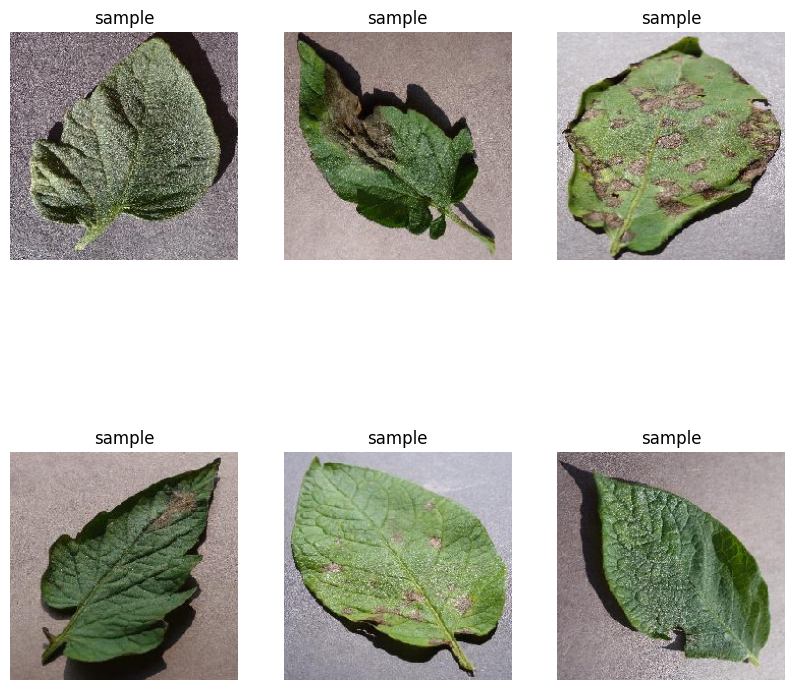

In [4]:

import matplotlib.pyplot as plt

images, labels = next(train_data)

plt.figure(figsize=(10,10))
for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(images[i])
    plt.title("sample")
    plt.axis('off')
plt.show()

# Build CNN Model

In [5]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Input

model = Sequential([
    Input(shape=(224,224,3)),
    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dense(train_data.num_classes, activation='softmax')
])

# Compile and Train Model


In [6]:

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=15
)

Epoch 1/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 67s 3s/step - accuracy: 0.3200 - loss: 4.1665 - val_accuracy: 0.5800 - val_loss: 1.1339
Epoch 2/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 61s 3s/step - accuracy: 0.7383 - loss: 0.7984 - val_accuracy: 0.8400 - val_loss: 0.4973
Epoch 3/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 62s 3s/step - accuracy: 0.9233 - loss: 0.2509 - val_accuracy: 0.8667 - val_loss: 0.3567
Epoch 4/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 61s 3s/step - accuracy: 0.9750 - loss: 0.0988 - val_accuracy: 0.8867 - val_loss: 0.3882
Epoch 5/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 61s 3s/step - accuracy: 0.9833 - loss: 0.0462 - val_accuracy: 0.9267 - val_loss: 0.2980
Epoch 6/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 61s 3s/step - accuracy: 0.9850 - loss: 0.0650 - val_accuracy: 0.8733 - val_loss: 0.4951
Epoch 7/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 62s 3s/step - accuracy: 0.9983 - loss: 0.0205 - val_accuracy: 0.9267 - val_loss: 0.2386
Epoch 8/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 62s 3s/step - accuracy: 0.9983 - loss: 0.0105 - val_accuracy: 0.9400 - val_loss:

# Plot Accuracy & Loss

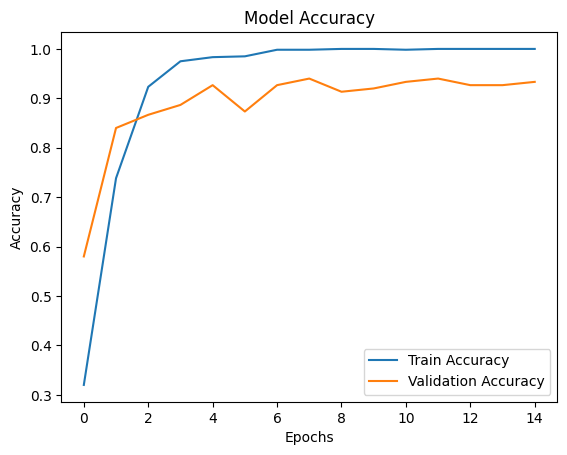

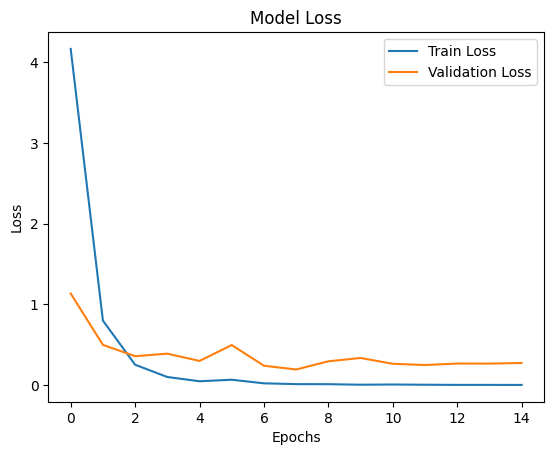

In [7]:

import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

after 4 layers

Epoch 1/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 94s 5s/step - accuracy: 0.3200 - loss: 1.4179 - val_accuracy: 0.3667 - val_loss: 1.2112
Epoch 2/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 90s 5s/step - accuracy: 0.5833 - loss: 0.9692 - val_accuracy: 0.6867 - val_loss: 0.8586
Epoch 3/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 90s 5s/step - accuracy: 0.7733 - loss: 0.5791 - val_accuracy: 0.7667 - val_loss: 0.5130
Epoch 4/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 88s 5s/step - accuracy: 0.7850 - loss: 0.6629 - val_accuracy: 0.7933 - val_loss: 0.6018
Epoch 5/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 99s 5s/step - accuracy: 0.8767 - loss: 0.3407 - val_accuracy: 0.9067 - val_loss: 0.2865
Epoch 6/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 94s 5s/step - accuracy: 0.9383 - loss: 0.1804 - val_accuracy: 0.9133 - val_loss: 0.2917
Epoch 7/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 89s 5s/step - accuracy: 0.9550 - loss: 0.1365 - val_accuracy: 0.8333 - val_loss: 0.4544
Epoch 8/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 90s 5s/step - accuracy: 0.9633 - loss: 0.1088 - val_accuracy: 0.9000 - val_loss:

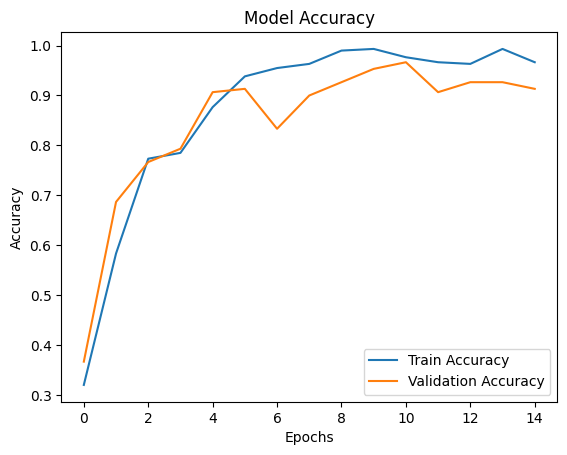

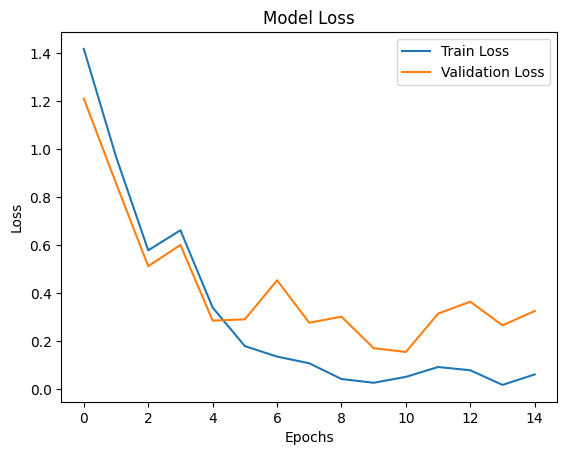

In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Input

model = Sequential([
    Input(shape=(224,224,3)),
    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(256, (3,3), activation='relu'),
    MaxPooling2D(2,2),


    Flatten(),
    Dense(128, activation='relu'),
    Dense(train_data.num_classes, activation='softmax')
])


model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=15
)


import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Transfer Learning MODEL 1 - MobileNetV2
 (Before Tuning)


In [9]:
base_model = MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

x = tf.keras.layers.GlobalAveragePooling2D()(base_model.output)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(train_data.num_classes, activation='softmax')(x)

tl_model = Model(inputs=base_model.input, outputs=output)

tl_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

tl_history = tl_model.fit(
    train_data,
    validation_data=val_data,
    epochs=8
)

Epoch 1/8
19/19 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - accuracy: 0.7983 - loss: 0.5244 - val_accuracy: 0.9800 - val_loss: 0.0881
Epoch 2/8
19/19 ━━━━━━━━━━━━━━━━━━━━ 33s 2s/step - accuracy: 0.9750 - loss: 0.0864 - val_accuracy: 0.9867 - val_loss: 0.0545
Epoch 3/8
19/19 ━━━━━━━━━━━━━━━━━━━━ 33s 2s/step - accuracy: 0.9783 - loss: 0.0578 - val_accuracy: 0.9867 - val_loss: 0.0528
Epoch 4/8
19/19 ━━━━━━━━━━━━━━━━━━━━ 33s 2s/step - accuracy: 0.9867 - loss: 0.0389 - val_accuracy: 0.9800 - val_loss: 0.0492
Epoch 5/8
19/19 ━━━━━━━━━━━━━━━━━━━━ 34s 2s/step - accuracy: 0.9933 - loss: 0.0158 - val_accuracy: 0.9800 - val_loss: 0.0430
Epoch 6/8
19/19 ━━━━━━━━━━━━━━━━━━━━ 32s 2s/step - accuracy: 0.9950 - loss: 0.0191 - val_accuracy: 0.9800 - val_loss: 0.0487
Epoch 7/8
19/19 ━━━━━━━━━━━━━━━━━━━━ 31s 2s/step - accuracy: 0.9967 - loss: 0.0137 - val_accuracy: 0.9800 - val_loss: 0.0407
Epoch 8/8
19/19 ━━━━━━━━━━━━━━━━━━━━ 33s 2s/step - accuracy: 0.9983 - loss: 0.0098 - val_accuracy: 0.9800 - val_loss: 0.0453


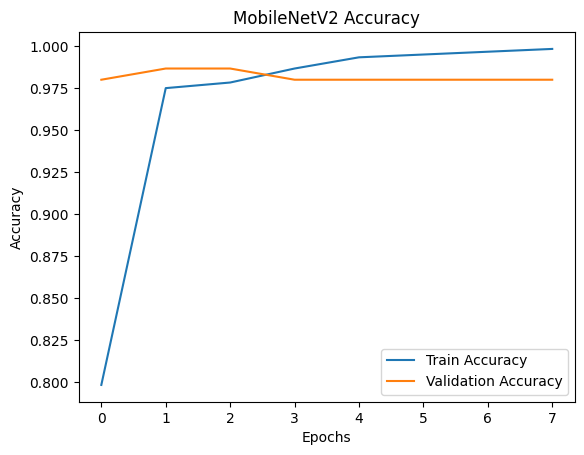

In [10]:
plt.plot(
    tl_history.history['accuracy'],
    label='Train Accuracy'
)

plt.plot(
    tl_history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title("MobileNetV2 Accuracy")

plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.legend()

plt.show()

# Transfer Learning MODEL 1 - MobileNetV2

(After Tuning )

In this i just did

Tuned learning rate ( Reduce learning rate automatically)

Early stopping

In [11]:
base_model = MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

x = tf.keras.layers.GlobalAveragePooling2D()(base_model.output)

x = Dense(
    256,
    activation='relu'
)(x)

x = Dropout(0.5)(x)

output = Dense(
    train_data.num_classes,
    activation='softmax'
)(x)

tl_model = Model(
    inputs=base_model.input,
    outputs=output
)


tl_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0001
    ),

    loss='categorical_crossentropy',

    metrics=['accuracy']
)


early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)


reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=2
)

tl_history = tl_model.fit(
    train_data,

    validation_data=val_data,

    epochs=15,

    callbacks=[
        early_stop,
        reduce_lr
    ]
)

Epoch 1/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 42s 2s/step - accuracy: 0.3900 - loss: 1.4056 - val_accuracy: 0.8400 - val_loss: 0.7219 - learning_rate: 1.0000e-04
Epoch 2/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 32s 2s/step - accuracy: 0.7333 - loss: 0.7036 - val_accuracy: 0.9200 - val_loss: 0.3878 - learning_rate: 1.0000e-04
Epoch 3/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 46s 2s/step - accuracy: 0.8867 - loss: 0.3989 - val_accuracy: 0.9467 - val_loss: 0.2542 - learning_rate: 1.0000e-04
Epoch 4/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 36s 2s/step - accuracy: 0.9267 - loss: 0.2713 - val_accuracy: 0.9533 - val_loss: 0.1920 - learning_rate: 1.0000e-04
Epoch 5/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 32s 2s/step - accuracy: 0.9583 - loss: 0.2124 - val_accuracy: 0.9533 - val_loss: 0.1560 - learning_rate: 1.0000e-04
Epoch 6/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 32s 2s/step - accuracy: 0.9650 - loss: 0.1622 - val_accuracy: 0.9667 - val_loss: 0.1308 - learning_rate: 1.0000e-04
Epoch 7/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 33s 2s/step - accuracy: 0.9683 - loss:

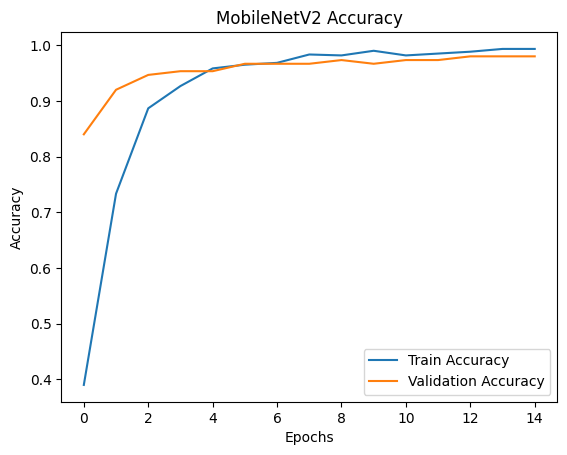

In [12]:
plt.plot(
    tl_history.history['accuracy'],
    label='Train Accuracy'
)

plt.plot(
    tl_history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title("MobileNetV2 Accuracy")

plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.legend()

plt.show()

#EfficientNetB0 Model

In [13]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D

base_model = EfficientNetB0(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

x = GlobalAveragePooling2D()(base_model.output)

x = Dense(
    256,
    activation='elu'
)(x)

output = Dense(
    train_data.num_classes,
    activation='softmax'
)(x)

efficient_model = Model(
    inputs=base_model.input,
    outputs=output
)

efficient_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

efficient_history = efficient_model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 72s 3s/step - accuracy: 0.2267 - loss: 1.6954 - val_accuracy: 0.2667 - val_loss: 1.4894
Epoch 2/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 56s 3s/step - accuracy: 0.2250 - loss: 1.5280 - val_accuracy: 0.2667 - val_loss: 1.5045
Epoch 3/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 67s 4s/step - accuracy: 0.2333 - loss: 1.4399 - val_accuracy: 0.2667 - val_loss: 1.4017
Epoch 4/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 54s 3s/step - accuracy: 0.2733 - loss: 1.4322 - val_accuracy: 0.2667 - val_loss: 1.4264
Epoch 5/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 55s 3s/step - accuracy: 0.2617 - loss: 1.4046 - val_accuracy: 0.2667 - val_loss: 1.3813
Epoch 6/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 67s 4s/step - accuracy: 0.2850 - loss: 1.4182 - val_accuracy: 0.2000 - val_loss: 1.4452
Epoch 7/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 58s 3s/step - accuracy: 0.2567 - loss: 1.4534 - val_accuracy: 0.2000 - val_loss: 1.4283
Epoch 8/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 56s 3s/step - accuracy: 0.2767 - loss: 1.4206 - val_accuracy: 0.2667 - val_loss:

#EfficientNetB0 Accuracy and loss Graph

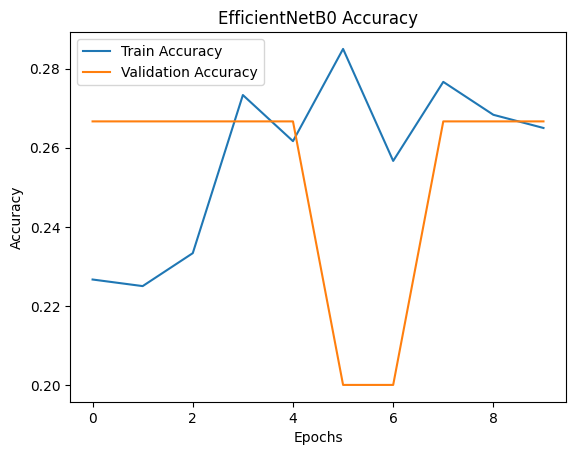

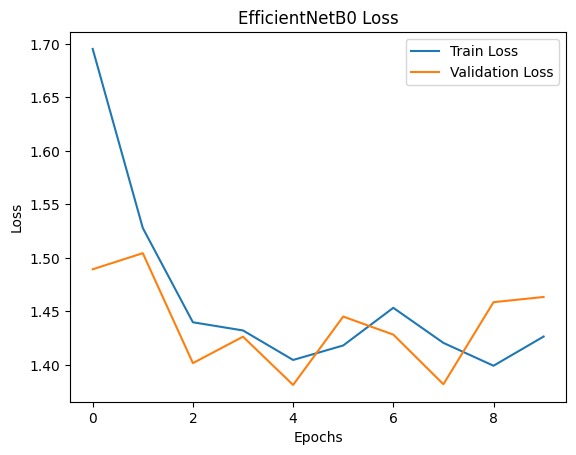

In [14]:

plt.plot(
    efficient_history.history['accuracy'],
    label='Train Accuracy'
)

plt.plot(
    efficient_history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title("EfficientNetB0 Accuracy")

plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.legend()

plt.show()






plt.plot(
    efficient_history.history['loss'],
    label='Train Loss'
)

plt.plot(
    efficient_history.history['val_loss'],
    label='Validation Loss'
)

plt.title("EfficientNetB0 Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.legend()

plt.show()

### Comparison of MobileNetV2 and EfficientNetB0 Accuracy Curves

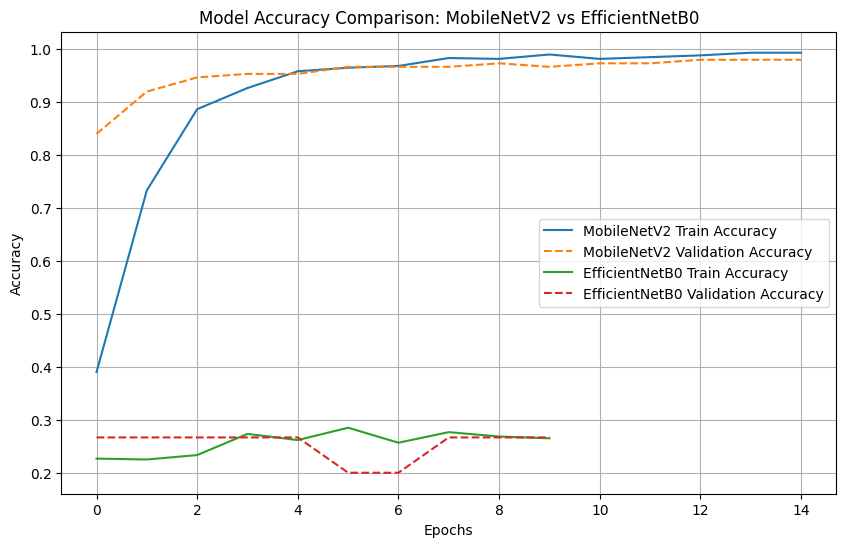

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Plot MobileNetV2 accuracies
plt.plot(tl_history.history['accuracy'], label='MobileNetV2 Train Accuracy', linestyle='-')
plt.plot(tl_history.history['val_accuracy'], label='MobileNetV2 Validation Accuracy', linestyle='--')

# Plot EfficientNetB0 accuracies
plt.plot(efficient_history.history['accuracy'], label='EfficientNetB0 Train Accuracy', linestyle='-')
plt.plot(efficient_history.history['val_accuracy'], label='EfficientNetB0 Validation Accuracy', linestyle='--')

plt.title('Model Accuracy Comparison: MobileNetV2 vs EfficientNetB0')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()